In [1]:
#Import libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Helper functions

def load_grayscale_image(image_path):
    """
    Load an image in grayscale mode and check if it exists.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    return image


def convert_to_binary(gray_image):
    """
    Convert grayscale image to binary using Otsu thresholding.
    """
    _, binary = cv2.threshold(
        gray_image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return binary


def show_images(images, titles, rows, cols, figsize=(12, 8)):
    """
    Display multiple images using matplotlib.
    """
    plt.figure(figsize=figsize)
    
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

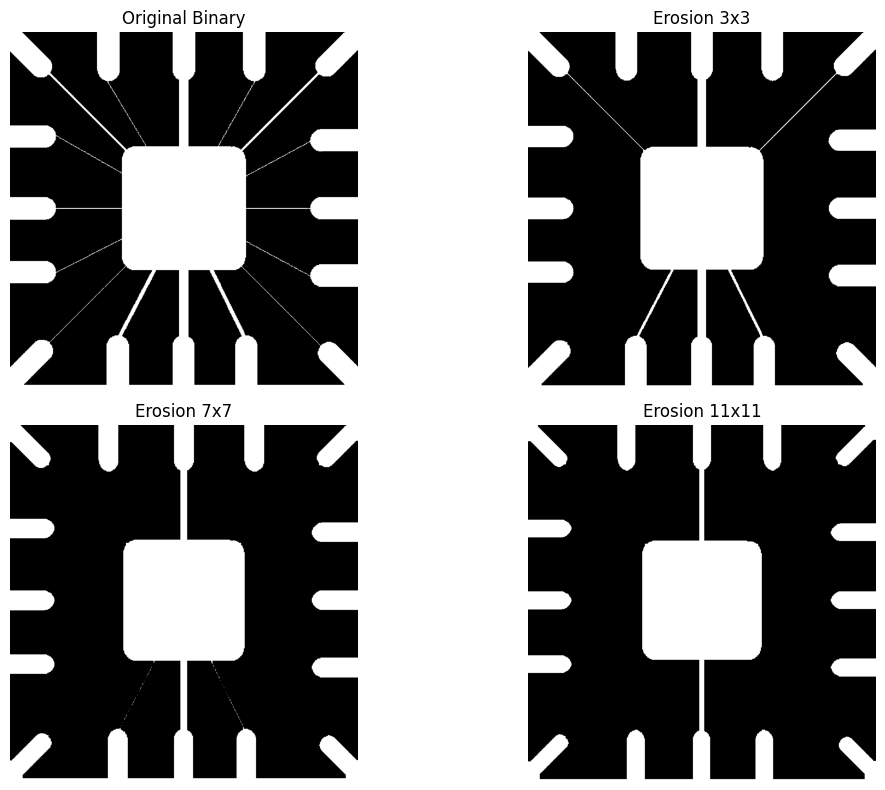

In [3]:
#Erosion Operation

imgFile = 'Erosion.jpg'

img = load_grayscale_image(imgFile)
binary = convert_to_binary(img)

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

eroded_img3 = cv2.erode(binary, kernel3, iterations=1)
eroded_img7 = cv2.erode(binary, kernel7, iterations=1)
eroded_img11 = cv2.erode(binary, kernel11, iterations=1)

show_images(
    [binary, eroded_img3, eroded_img7, eroded_img11],
    ['Original Binary', 'Erosion 3x3', 'Erosion 7x7', 'Erosion 11x11'],
    2,
    2
)

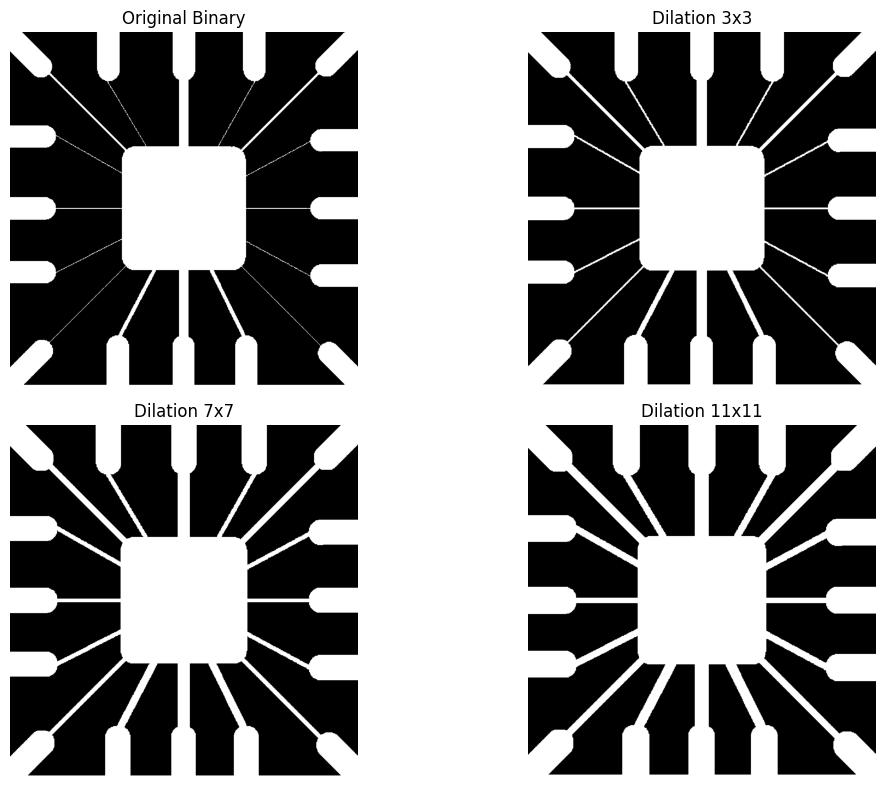

In [4]:
#Dilation Operation

imgFile = 'Erosion.jpg'

img = load_grayscale_image(imgFile)
binary = convert_to_binary(img)

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

dilated_img3 = cv2.dilate(binary, kernel3, iterations=1)
dilated_img7 = cv2.dilate(binary, kernel7, iterations=1)
dilated_img11 = cv2.dilate(binary, kernel11, iterations=1)

show_images(
    [binary, dilated_img3, dilated_img7, dilated_img11],
    ['Original Binary', 'Dilation 3x3', 'Dilation 7x7', 'Dilation 11x11'],
    2,
    2
)

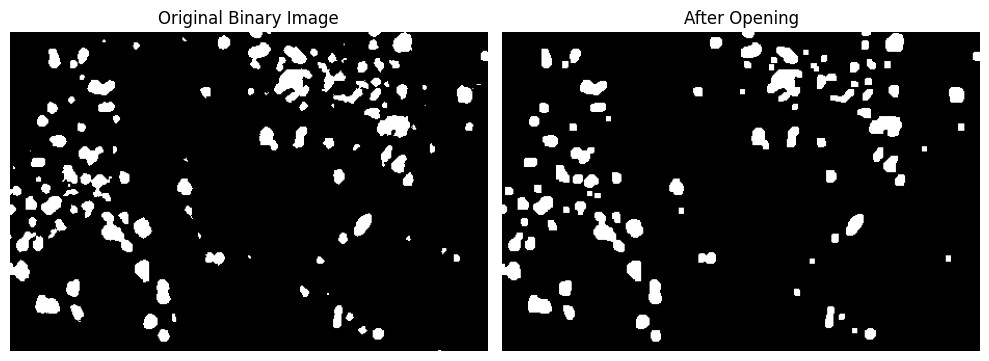

In [5]:
#Morphological Opening

imgFile = 'Open_Closing.jpg'

img = load_grayscale_image(imgFile)
binary = convert_to_binary(img)

kernel = np.ones((5, 5), np.uint8)

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

show_images(
    [binary, opening],
    ['Original Binary Image', 'After Opening'],
    1,
    2,
    figsize=(10, 5)
)

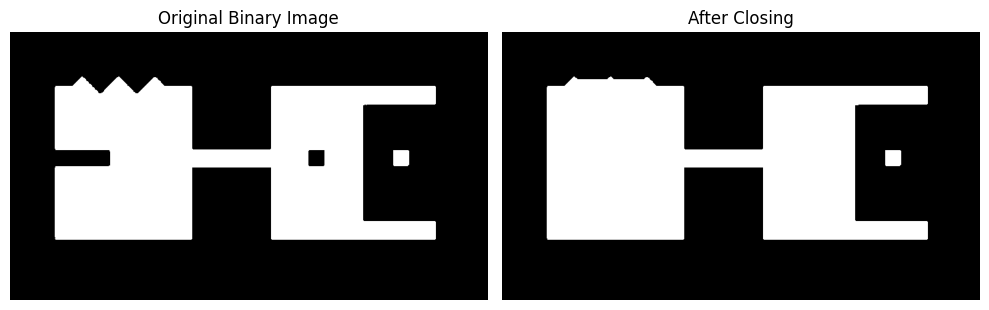

In [6]:
#Morphological Closing

imgFile = 'Opening2.jpg'

img = load_grayscale_image(imgFile)
binary = convert_to_binary(img)

kernel = np.ones((45, 45), np.uint8)

closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

show_images(
    [binary, closing],
    ['Original Binary Image', 'After Closing'],
    1,
    2,
    figsize=(10, 5)
)

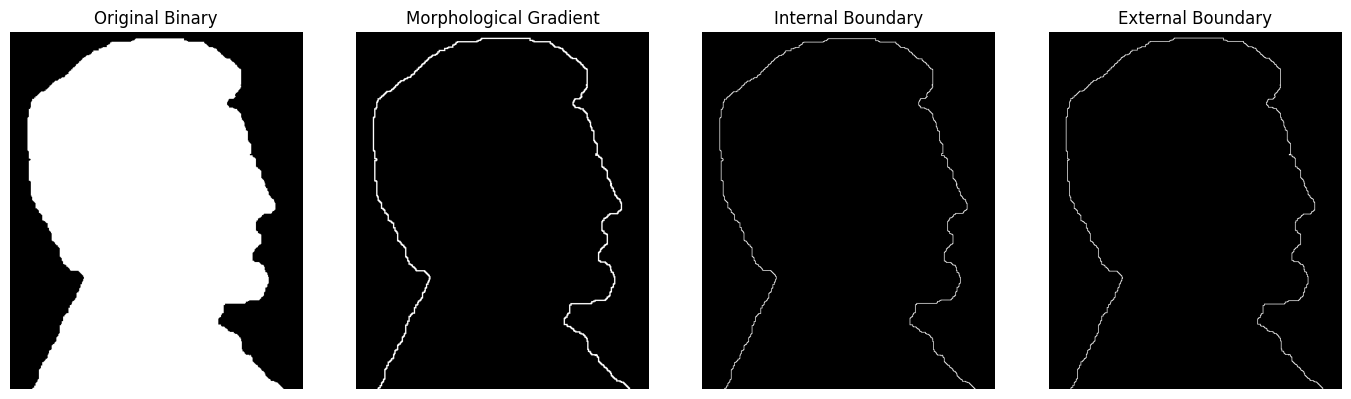

In [7]:
#Boundary Extraction

imgFile = 'BoundaryExtraction.jpg'

img = load_grayscale_image(imgFile)
binary = convert_to_binary(img)

kernel = np.ones((3, 3), np.uint8)

gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

eroded = cv2.erode(binary, kernel, iterations=1)
internal_boundary = cv2.subtract(binary, eroded)

dilated = cv2.dilate(binary, kernel, iterations=1)
external_boundary = cv2.subtract(dilated, binary)

show_images(
    [binary, gradient, internal_boundary, external_boundary],
    ['Original Binary', 'Morphological Gradient', 'Internal Boundary', 'External Boundary'],
    1,
    4,
    figsize=(14, 4)
)

In [8]:
# Cell 8: Final confirmation

print("All required morphological operations were completed successfully:")
print("1. Erosion using 3x3, 7x7, and 11x11 kernels")
print("2. Dilation using 3x3, 7x7, and 11x11 kernels")
print("3. Opening using 5x5 kernel")
print("4. Closing using 45x45 kernel")
print("5. Boundary extraction using Gradient, Internal Boundary, and External Boundary")

All required morphological operations were completed successfully:
1. Erosion using 3x3, 7x7, and 11x11 kernels
2. Dilation using 3x3, 7x7, and 11x11 kernels
3. Opening using 5x5 kernel
4. Closing using 45x45 kernel
5. Boundary extraction using Gradient, Internal Boundary, and External Boundary
